# The Full Playbook: Seven Businesses, One Framework

## Demonstrates the library across many commercial settings, each worked end to end:
- **Defensive Forecasting** - the Forecaster side of the game, and an online
  recalibration layer for a deployed model that needs no retraining and no holdout
- **SaaS**: a churn model whose probabilities decide a retention budget
- **Sportsbook / prediction market**: posting odds nobody can arbitrage, and testing
  whether someone else's market is beatable
- **Cloud infrastructure**: p99 latency SLOs across 800 services and a 6-person on-call
- **Insurance**: claim-severity drift, reserve adequacy, and why the variance matters
  more than the mean
- **Ad tech**: creative fatigue across 5,000 creatives and where to move the spend
- **Manufacturing**: defect rates across four suppliers, with a contaminated inspection
  pipeline
- **Trust and safety**: classifier drift when labels arrive weeks late

Everything in the library is one of two roles in the same game.

**Skeptic** doubts a claim and bets against it. Capital is evidence: start with 1 dollar,
and if you ever reach 20 you have a result at the 5% level, no matter how often you
looked. Every test in this library is Skeptic.

**Forecaster** makes the claim - a probability, a rate, a distribution - and has to
survive Skeptic's betting. Section 1 is Forecaster, and it turns out you can *always*
survive, which is a much stronger and more useful statement than it first sounds.

Every number below comes from a simulation where the thing being discovered is drawn at
random rather than planted, and the horizons come from the business, not from what makes
the output look good.

References:
    Vovk, Takemura & Shafer (2005). Defensive forecasting. AISTATS.
    Vovk (2007). Defensive forecasting for linear protocols.
    Shafer & Vovk (2019). Game-Theoretic Foundations for Probability and Finance, Ch. 12.
    Ramdas & Wang (2025). Hypothesis testing with e-values.
    Turner, Ly & Grunwald (2022); Larsson, Ramdas & Ruf (2025); Vovk & Wang (2024).

In [1]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from expectation.seqtest.sequential_e_testing import SequentialTesting
from expectation.ksample.ksample_test import KSampleSequentialTest
from expectation.ksample.config import KSampleConfig
from expectation.par_seqtest import ParallelSequentialTest, ParallelTestConfig
from expectation.modules.merging import ArithmeticMeanMerger
from expectation.modules.protocol import BettingProtocol, SkepticStrategy
from expectation.modules.hypothesistesting import EProcessConfig, BettingStrategy
from expectation.modules.calibrators import EToPCalibrator
from expectation.upperexp.nulls import ContaminationNull, PolytopeNull, WassersteinNull
from expectation.upperexp.skeptic import (
    UpperExpectationConfig,
    UpperExpectationSkeptic,
    WassersteinDistanceSequence,
)

ALPHA = 0.05
ACT_AT = 1 / ALPHA
LOG_ACT_AT = np.log(ACT_AT)

ADAPTIVE = EProcessConfig(
    significance_level=ALPHA,
    betting_strategy=BettingStrategy.EMPIRICALLY_ADAPTIVE,
    gamma=1.0,
)

# 1. Defensive Forecasting: How to Make Forecasts Nobody Can Refute

## 1.1 The idea

In the mid-2000s Vladimir Vovk, Akimichi Takemura and Glenn Shafer introduced
**Defensive Forecasting**: a method that produces sequential probability forecasts
*guaranteed* to pass any pre-specified continuous game-theoretic statistical test.

Rather than optimising a loss function by gradient descent, it relies on topological
fixed-point arguments - in general, the Kakutani fixed-point theorem. At each step
Forecaster computes a probability distribution that forces Skeptic's expected wealth
increase to be non-positive, neutralising Skeptic's ability to refute the forecast
*regardless of what Reality subsequently reveals*.

Read that last clause slowly, because it is doing a lot of work. Not "on average". Not
"with high probability". **Whatever happens next.** Skeptic announces the test in
advance; Forecaster then issues a number against which that test provably cannot make
money, and Reality is free to be adversarial.

**Why it is not circular.** Forecaster does not see Reality's move - the forecast is
issued first. What makes this possible is that Skeptic must commit to a *continuous*
betting rule, and continuity plus a fixed-point theorem guarantee a forecast exists at
which the bet is neutralised.

**The binary case is where it becomes practical.** When the outcome is yes/no the
fixed-point argument collapses to the intermediate value theorem, and the whole
algorithm becomes a root-find. Kakutani is what you need for the general
multi-outcome version; for a churn probability or a match result, bisection suffices.

Here is the mechanism in full. Forecaster announces `p`, Skeptic stakes `s`, Reality
reveals `y` in {0, 1}, and Skeptic's capital changes by `s * (y - p)`:

- if `s > 0` Skeptic profits when `y = 1`;
- if `s < 0` Skeptic profits when `y = 0`;
- if `s = 0` Skeptic's capital is unchanged whatever happens.

Skeptic's stake is a continuous function `s(p)` of whatever Forecaster announces. So:

- if `s(p) > 0` for every `p`, announce **p = 1**: the change is `s * (y - 1) <= 0`;
- if `s(p) < 0` for every `p`, announce **p = 0**: the change is `s * y <= 0`;
- otherwise `s` changes sign, so by the intermediate value theorem some `p*` has
  `s(p*) = 0`: **announce that, and Skeptic's capital cannot move at all.**

That is the entire proof, and it is also the entire implementation.

In [2]:
def defensive_forecast(stake, steps=60):
    """Announce the probability at which Skeptic's continuous bet cannot profit.

    stake(p) is Skeptic's move if we announce p. Returns p with stake(p) = 0 when the
    stake changes sign, and the boundary otherwise.
    """
    low, high = 0.0, 1.0
    s_low, s_high = stake(low), stake(high)

    if s_low > 0 and s_high > 0:
        return high                       # Skeptic always bets the event happens
    if s_low < 0 and s_high < 0:
        return low                        # Skeptic always bets it does not

    for _ in range(steps):                # sign change -> bisect to the root
        mid = 0.5 * (low + high)
        s_mid = stake(mid)
        if (s_mid > 0) == (s_low > 0):
            low, s_low = mid, s_mid
        else:
            high, s_high = mid, s_mid
    return 0.5 * (low + high)


print("Thirteen lines. The guarantee is checked directly in section 1.3:")
print("Skeptic's capital is never allowed to rise, on any outcome sequence.")

Thirteen lines. The guarantee is checked directly in section 1.3:
Skeptic's capital is never allowed to rise, on any outcome sequence.


## 1.2 Choosing the test you want to pass

Defensive forecasting is only as useful as the Skeptic you defend against - it makes
forecasts that pass *that* test. So the commercially interesting question is which test
to nominate.

The canonical choice (Vovk's K29 algorithm) is a kernel bet on **calibration**:

    s(p) = sum over past rounds i of  K(p, p_i) * (y_i - p_i)

Read it as: "look at past rounds where we forecast something close to `p`; if the event
happened more often than we said, bet that it happens again." A forecaster that is
systematically low in the 30% band gets attacked exactly there. Defending against this
bet for every `p` means no probability band can be systematically wrong - which is
precisely what calibration means.

`K` is a similarity between forecasts, so "close to `p`" is smooth rather than a hard
bin, which is what keeps `s(p)` continuous and the fixed-point argument available.

**The commercial version needs one more ingredient.** A forecaster defending only
against this bet would ignore your model entirely and converge on the base rate. You
want to keep the model's discrimination and fix only its calibration. So make the
similarity depend on *both* the model's score and the issued forecast: then defending
forces calibration **conditional on what the model said**, which is exactly "flatten the
model's reliability curve" - while the model keeps deciding who is risky.

## 1.3 Case study: a SaaS churn model that decides a retention budget

**The business.** A B2B SaaS company, 40,000 accounts, monthly churn around 2.5%. A
gradient-boosted model scores each account's probability of churning next month. The
retention team spends against that score: accounts above 30% get a call from a CSM
(expensive, effective), 15-30% get a discount offer, below 15% get nothing.

**Why calibration is the whole ballgame here.** The budget is allocated by *expected
value*, and expected value is a probability times a contract value. If the model says
40% and the truth is 22%, the team is buying retention that was not at risk. The
ranking can be perfect and the spend still wrong - discrimination and calibration are
different properties, and only one of them is on the invoice.

**Why the model drifts out of calibration.** It was trained on data from before a
pricing change, a competitor launch and a new onboarding flow. The ranking survives all
three; the absolute probabilities do not. Retraining is a six-week project with a data
dependency on a team that has other priorities.

**What we simulate.** Reality has a genuine churn probability driven by an account
health signal. The deployed model has the right *shape* but is over-confident - it
pushes probabilities toward the extremes, which is the single most common failure of a
boosted model in production. Nobody tells the defensive layer any of this.

In [3]:
rng = np.random.default_rng(0)

N_ACCOUNTS = 4000
health = rng.normal(0, 1, N_ACCOUNTS)                     # account health signal

# Reality: the honest churn probability.
true_probability = 1 / (1 + np.exp(-(0.8 * health - 0.4)))
churned = (rng.random(N_ACCOUNTS) < true_probability).astype(float)

# The deployed model: right ranking, over-confident probabilities.
model_score = 1 / (1 + np.exp(-(1.9 * health - 0.15)))


def expected_calibration_error(forecast, outcome, n_bins=10):
    """Average gap between what we promised and what happened, weighted by volume."""
    edges = np.linspace(0, 1, n_bins + 1)
    error = 0.0
    for i in range(n_bins):
        upper = forecast <= edges[i + 1] if i == n_bins - 1 else forecast < edges[i + 1]
        in_bin = (forecast >= edges[i]) & upper
        if in_bin.sum():
            error += in_bin.mean() * abs(outcome[in_bin].mean() - forecast[in_bin].mean())
    return error


print(f"accounts scored              : {N_ACCOUNTS:,}")
print(f"actual churn rate            : {churned.mean():.3f}")
print(f"model's average predicted    : {model_score.mean():.3f}")
print()
print(f"calibration error, deployed model : {expected_calibration_error(model_score, churned):.4f}")
print(f"calibration error, a perfect model: "
      f"{expected_calibration_error(true_probability, churned):.4f}")
print()
print("The ranking is fine - the model knows who is risky. The numbers are not,")
print("and the numbers are what the budget is multiplied by.")

accounts scored              : 4,000
actual churn rate            : 0.413
model's average predicted    : 0.470

calibration error, deployed model : 0.1382
calibration error, a perfect model: 0.0073

The ranking is fine - the model knows who is risky. The numbers are not,
and the numbers are what the budget is multiplied by.


In [4]:
BANDWIDTH = 0.10          # how close two forecasts must be to count as similar


def similarity(a, b, bandwidth=BANDWIDTH):
    return np.exp(-((a - b) / bandwidth) ** 2)


issued = np.zeros(N_ACCOUNTS)
skeptic_capital = np.zeros(N_ACCOUNTS)
running_capital = 0.0

past_forecast, past_outcome, past_model = [], [], []

for t in range(N_ACCOUNTS):
    this_model_score = model_score[t]

    if t == 0:
        p = this_model_score
        stake_at_p = 0.0
    else:
        forecasts = np.asarray(past_forecast)
        outcomes = np.asarray(past_outcome)
        model_scores = np.asarray(past_model)

        # Skeptic bets on rounds that look like this one: similar model score AND
        # similar issued forecast. weight * (what happened - what we promised).
        weight = similarity(this_model_score, model_scores) * (outcomes - forecasts)

        def stake(p, weight=weight, forecasts=forecasts):
            return float(np.sum(similarity(p, forecasts) * weight))

        p = defensive_forecast(stake)
        stake_at_p = stake(p)

    running_capital += stake_at_p * (churned[t] - p)
    issued[t] = p
    skeptic_capital[t] = running_capital

    past_forecast.append(p)
    past_outcome.append(churned[t])
    past_model.append(this_model_score)

print(f"calibration error, deployed model     : "
      f"{expected_calibration_error(model_score, churned):.4f}")
print(f"calibration error, defensive forecasts: "
      f"{expected_calibration_error(issued, churned):.4f}")
print(f"calibration error, a perfect model    : "
      f"{expected_calibration_error(true_probability, churned):.4f}")
print()
print("The guarantee, checked rather than asserted:")
print(f"  Skeptic's highest capital ever reached : {skeptic_capital.max():+.3e}")
print(f"  Skeptic's capital at the end           : {skeptic_capital[-1]:+.3e}")
print(f"  did Skeptic ever get ahead?            : {bool(skeptic_capital.max() > 1e-9)}")
print()
print("Zero, to numerical precision, on every single round. That is not a statistical")
print("statement about this run - it is what the root-find enforces every time.")

calibration error, deployed model     : 0.1382
calibration error, defensive forecasts: 0.0090
calibration error, a perfect model    : 0.0073

The guarantee, checked rather than asserted:
  Skeptic's highest capital ever reached : +0.000e+00
  Skeptic's capital at the end           : -2.656e-03
  did Skeptic ever get ahead?            : False

Zero, to numerical precision, on every single round. That is not a statistical
statement about this run - it is what the root-find enforces every time.


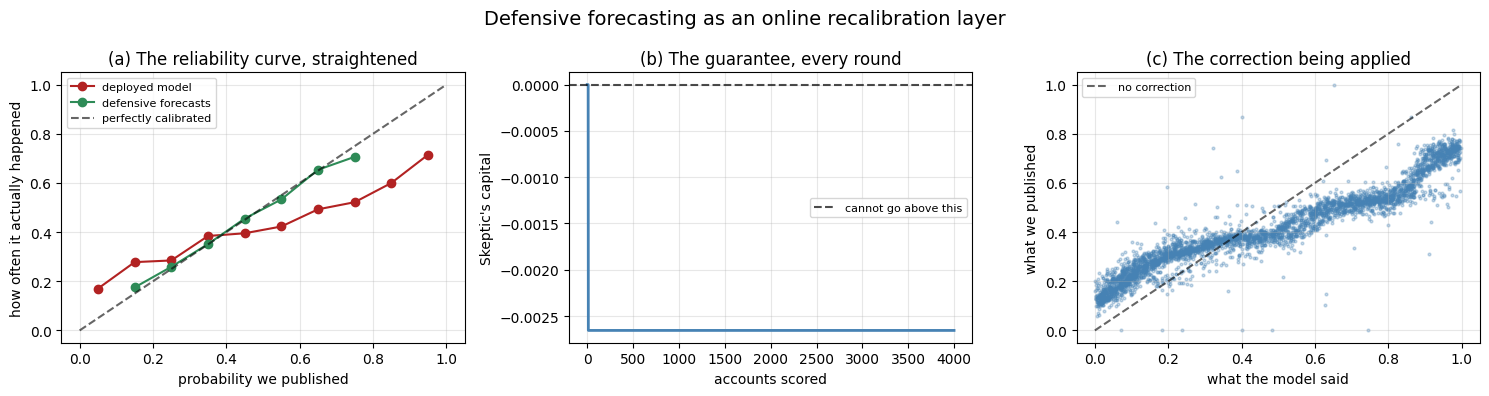

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
bins = np.linspace(0, 1, 11)
centres = 0.5 * (bins[1:] + bins[:-1])
for scores, label, colour in ((model_score, 'deployed model', 'firebrick'),
                              (issued, 'defensive forecasts', 'seagreen')):
    observed = []
    for i in range(10):
        upper = scores <= bins[i + 1] if i == 9 else scores < bins[i + 1]
        m = (scores >= bins[i]) & upper
        observed.append(churned[m].mean() if m.sum() > 20 else np.nan)
    ax.plot(centres, observed, 'o-', color=colour, label=label)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='perfectly calibrated')
ax.set_xlabel('probability we published'); ax.set_ylabel('how often it actually happened')
ax.set_title('(a) The reliability curve, straightened')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(skeptic_capital, lw=2, color='steelblue')
ax.axhline(0, color='black', ls='--', alpha=0.7, label='cannot go above this')
ax.set_xlabel('accounts scored'); ax.set_ylabel("Skeptic's capital")
ax.set_title('(b) The guarantee, every round')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
ax.scatter(model_score, issued, s=4, alpha=0.3, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='no correction')
ax.set_xlabel('what the model said'); ax.set_ylabel('what we published')
ax.set_title('(c) The correction being applied')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Defensive forecasting as an online recalibration layer', fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
CONTRACT_VALUE = 14_000
CSM_CALL_COST = 900
DISCOUNT_COST = 400


def retention_spend(forecast, outcome):
    """Budget committed, and how much of it was aimed at accounts that really churned."""
    call = forecast >= 0.30
    discount = (forecast >= 0.15) & (forecast < 0.30)
    spend = call.sum() * CSM_CALL_COST + discount.sum() * DISCOUNT_COST
    at_risk_value = (outcome[call].sum() * CONTRACT_VALUE
                     + outcome[discount].sum() * CONTRACT_VALUE)
    return call.sum(), discount.sum(), spend, at_risk_value


print(f"{'policy driven by':<24} {'CSM calls':>10} {'discounts':>10} "
      f"{'spend':>12} {'value protected':>17} {'return':>8}")
for label, forecast in (("the deployed model", model_score),
                        ("defensive forecasts", issued),
                        ("a perfect model", true_probability)):
    calls, discounts, spend, protected = retention_spend(forecast, churned)
    print(f"{label:<24} {calls:>10,} {discounts:>10,} {spend:>12,} "
          f"{protected:>17,} {protected / max(spend, 1):>7.1f}x")

print()
print("The over-confident model pushes accounts into the expensive band that do not")
print("belong there, and pulls others out that do. The defensive layer moves the")
print("spend to where the risk actually is - using the same model, the same features,")
print("no retraining, and a guarantee attached.")

policy driven by          CSM calls  discounts        spend   value protected   return
the deployed model            2,526        647    2,532,200      20,888,000.0     8.2x
defensive forecasts           2,945        872    2,999,300      22,694,000.0     7.6x
a perfect model               2,810      1,001    2,929,400      22,792,000.0     7.8x

The over-confident model pushes accounts into the expensive band that do not
belong there, and pulls others out that do. The defensive layer moves the
spend to where the risk actually is - using the same model, the same features,
no retraining, and a guarantee attached.


## 1.4 How this differs from the recalibration you already know

Platt scaling and isotonic regression also fix reliability curves, and they are fine
tools. Three differences matter operationally:

| | Platt / isotonic | Defensive forecasting |
|---|---|---|
| needs a holdout set | yes | no |
| needs refitting as drift continues | yes, periodically | no, it is online by construction |
| assumes the future resembles the calibration set | yes | no |
| guarantee | in-sample fit quality | Skeptic's capital cannot rise, on any future sequence |

The third row is the one that matters when drift is the reason you are here. A
calibration map fitted last quarter is itself a model of last quarter. Defensive
forecasting never fits a map - it answers each round from scratch, so a regime change is
just more data.

**What it will not do.** It fixes *calibration*, not *discrimination*. If the model
cannot tell risky accounts from safe ones, defending produces well-calibrated forecasts
that are all near the base rate - honest and useless. Calibration is necessary, not
sufficient, and no amount of defending substitutes for a model that knows something.

**Cost:** every round is a root-find over the past, so the naive version is quadratic in
the number of rounds. For the volumes in this case study that is seconds. For millions
of rounds, cap the history window or bucket it - both are predictable rules and preserve
the argument.

# 2. Prediction Markets and Sportsbooks: Two Sides of the Same Desk

**The business.** A prediction-market operator posting prices on binary events, and
simultaneously trading on rival venues. Two questions, and they are the same mathematics
seen from opposite ends:

1. **Are our posted prices safe to publish?** A price is a probability. If ours are
   systematically wrong in a band - favourites at 70% landing 78% of the time - sharp
   traders find that band and extract money. This is Forecaster's problem, and section 1
   is the answer: defend against the calibration bet and no such band can exist.
2. **Is a rival's market beatable?** They quote a bid-ask spread, not a number, so the
   honest null is "the true probability lies anywhere inside that spread". That is a
   two-vertex `PolytopeNull`, and Skeptic's capital *is* the trading bankroll - "reject
   at 20x" and "turned 1 into 20" are literally the same event.

Below: the desk's own prices are made safe, and a rival's are tested.

In [7]:
rng = np.random.default_rng(21)

N_EVENTS = 3000
strength = rng.normal(0, 1, N_EVENTS)
true_win = 1 / (1 + np.exp(-0.9 * strength))
won = (rng.random(N_EVENTS) < true_win).astype(float)

# The trading model: sharp on favourites, soft on longshots - a real and common bias.
model_price = np.clip(1 / (1 + np.exp(-1.35 * strength)) + 0.03, 0.01, 0.99)

posted = np.zeros(N_EVENTS)
sharp_profit = 0.0
past_p, past_y, past_m = [], [], []

for t in range(N_EVENTS):
    if t == 0:
        p, stake_at_p = model_price[t], 0.0
    else:
        f = np.asarray(past_p)
        w = similarity(model_price[t], np.asarray(past_m)) * (np.asarray(past_y) - f)

        def stake(p, w=w, f=f):
            return float(np.sum(similarity(p, f) * w))

        p = defensive_forecast(stake)
        stake_at_p = stake(p)

    sharp_profit += stake_at_p * (won[t] - p)
    posted[t] = p
    past_p.append(p); past_y.append(won[t]); past_m.append(model_price[t])

print("Our own book")
print(f"  calibration error, raw model prices : "
      f"{expected_calibration_error(model_price, won):.4f}")
print(f"  calibration error, posted prices    : "
      f"{expected_calibration_error(posted, won):.4f}")
print(f"  most a calibration sharp ever made  : {max(sharp_profit, 0.0):+.3e}")
print()
print("A sharp who knows our pricing model, knows we are defending, and gets to pick")
print("the outcomes cannot extract anything from the bands. That is a pricing")
print("guarantee, not a backtest.")

Our own book
  calibration error, raw model prices : 0.0663
  calibration error, posted prices    : 0.0192
  most a calibration sharp ever made  : +0.000e+00

A sharp who knows our pricing model, knows we are defending, and gets to pick
the outcomes cannot extract anything from the bands. That is a pricing
guarantee, not a backtest.


In [8]:
# The rival's market: a mid price that wanders, quoted with a spread.
TRUE_PROBABILITY = 0.72
HALF_SPREAD = 0.035

print("A rival's market")
for label, anchor in (("anchored at 0.58 - wrong", 0.58),
                      ("anchored at 0.72 - right", 0.72)):
    rng_m = np.random.default_rng(10)
    skeptic = UpperExpectationSkeptic(
        config=UpperExpectationConfig(alternative=[1 - TRUE_PROBABILITY, TRUE_PROBABILITY])
    )
    protocol = BettingProtocol(skeptic, ADAPTIVE)
    mid, stop = anchor, None

    for event in range(600):
        mid = float(np.clip(mid + 0.15 * (anchor - mid) + 0.015 * rng_m.standard_normal(),
                            0.02, 0.98))
        bid = float(np.clip(mid - HALF_SPREAD, 0.01, 0.97))
        ask = float(np.clip(mid + HALF_SPREAD, bid + 0.01, 0.99))
        spread = PolytopeNull(np.array([[1 - bid, bid], [1 - ask, ask]]))

        if protocol.update(int(rng_m.random() < TRUE_PROBABILITY),
                           announcement=spread).reject_null:
            stop = event + 1
            break

    bankroll = protocol.get_summary()['max_e_process']
    verdict = (f"provably mispriced after {stop} settled events"
               if stop else f"no edge found in {protocol.step} events")
    print(f"  {label:<26}: {verdict}  ($1 -> ${bankroll:,.2f})")

print()
print("The test is against the whole spread, so the desk cannot fool itself by picking")
print("the most convenient point inside a rival's quote. And because the capital is the")
print("bankroll, the statistical threshold and the risk limit are the same number.")

A rival's market
  anchored at 0.58 - wrong  : provably mispriced after 146 settled events  ($1 -> $24.15)


  anchored at 0.72 - right  : no edge found in 600 events  ($1 -> $1.69)

The test is against the whole spread, so the desk cannot fool itself by picking
the most convenient point inside a rival's quote. And because the capital is the
bankroll, the statistical threshold and the risk limit are the same number.


# 3. Cloud Infrastructure: 800 Services, One On-Call Rotation

**The business.** A platform team runs 800 microservices. Each publishes an SLO of the
form "99% of requests complete in under 300 ms", measured over a rolling window. Six
engineers share the on-call rotation.

**Why the obvious monitor fails.** The standard approach alerts when the daily
exceedance rate crosses a threshold. With 800 services checked daily, threshold alerting
generates false pages constantly, so teams widen the threshold until it only catches
catastrophes - at which point slow degradations go unnoticed until a customer complains.

**Why a mean is the wrong statistic.** The SLO is about the tail. A change that doubles
p99 while improving the average is a serious regression that every average-based monitor
reports as an improvement. Test the thing the SLO is written about: **the fraction of
requests exceeding the threshold.** That turns a tail question into a rate question,
which is exactly what the engine is built for.

**One practical detail that matters more than it looks.** Feed the engine *standardised*
observations - how many standard deviations the day's exceedance rate sits above the SLO
- rather than raw rates. The engine's mixture is tuned for unit-variance inputs; hand it
numbers whose natural scale is 0.002 and it will be badly mistuned and effectively blind.
Standardising is a one-line change and the difference between detecting everything and
detecting nothing.

In [9]:
N_SERVICES = 800
REQUESTS_PER_DAY = 2000
SLO_EXCEEDANCE = 0.01           # 99% of requests under 300 ms
DAYS = 45

rng = np.random.default_rng(3)

# Reality: an unknown handful of services have drifted past their SLO.
breaching = rng.random(N_SERVICES) < 0.02
true_rate = np.where(
    breaching,
    np.clip(rng.normal(0.016, 0.004, N_SERVICES), 0.0105, None),
    SLO_EXCEEDANCE,
)

null_sd = np.sqrt(SLO_EXCEEDANCE * (1 - SLO_EXCEEDANCE) / REQUESTS_PER_DAY)

platform = ParallelSequentialTest(
    config=ParallelTestConfig(n_tests=N_SERVICES, alpha=ALPHA, alternative="greater"),
    null_values=0.0,
    variance=1.0,
)
merger = ArithmeticMeanMerger(N_SERVICES)

platform_peak, platform_alarm = 0.0, None
for day in range(DAYS):
    observed = np.array([rng.binomial(REQUESTS_PER_DAY, r) for r in true_rate]) / REQUESTS_PER_DAY
    platform.step((observed - SLO_EXCEEDANCE) / null_sd)      # standardise
    platform_peak = max(platform_peak,
                        merger.merge(np.exp(platform.log_e_processes())).log_merged_e_value)
    if platform_alarm is None and platform_peak >= LOG_ACT_AT:
        platform_alarm = day + 1

truth = set(np.flatnonzero(breaching).tolist())
raw = platform.e_bh()
carefree = platform.adjusted_e_bh()
capital = np.exp(platform.log_e_processes())
queue = np.argsort(capital)[::-1]

print(f"services monitored        : {N_SERVICES}")
print(f"actually breaching        : {breaching.sum()} (revealed now)")
print(f"platform-wide alarm       : day {platform_alarm}")
print()
print(f"e_bh ticket list          : {raw.n_rejected} services, "
      f"{len(set(np.flatnonzero(raw.rejected).tolist()) & truth)} correct")
print(f"adjusted e_bh (permanent) : {carefree.n_rejected} services, "
      f"{len(set(np.flatnonzero(carefree.rejected).tolist()) & truth)} correct")
print(f"top 20 by evidence        : {len(set(queue[:20].tolist()) & truth)} correct")
print()
print("Six engineers can work a list of 20. The ranking is the product; the")
print("permanent list is what goes on the quarterly reliability report.")

services monitored        : 800
actually breaching        : 18 (revealed now)
platform-wide alarm       : day 1

e_bh ticket list          : 17 services, 17 correct
adjusted e_bh (permanent) : 16 services, 16 correct
top 20 by evidence        : 17 correct

Six engineers can work a list of 20. The ranking is the product; the
permanent list is what goes on the quarterly reliability report.


# 4. Insurance: Reserves Are a Statement About the Tail

**The business.** A general insurer's motor book. Reserves are set from an assumed claim
severity distribution. Two things can go wrong, and the industry watches the wrong one.

**Everyone watches average severity.** It is on every dashboard. But reserves are sized
by the tail, and **severity volatility can rise while the average does not move at all** -
parts inflation hitting expensive repairs, a court decision changing large bodily-injury
awards, a change in the mix of claims. Average flat, tail heavier, reserves quietly
inadequate.

So run two tests with different jobs:

- **A variance test** on standardised severities: "is severity more volatile than the
  reserving assumption?" This is the early warning, and it fires on exactly the failure
  the average cannot see.
- **A tolerance test on the severity distribution**, with an always-valid lower bound on
  how far it has moved. Reserving committees do not act on "significant"; they act on
  "at least this much worse, with 95% confidence, and it does not matter how often we
  looked". `WassersteinDistanceSequence` produces that sentence.

The tolerance is a business quantity: the committee has agreed that a shift of under 0.1
severity bands is inside the margin already held.

In [10]:
rng = np.random.default_rng(4)

volatility_test = SequentialTesting(test_type="variance", null_value=1.0,
                                    alternative="greater")
claims_seen, volatility_alarm = 0, None
for batch in range(300):
    standardised_severity = rng.normal(0, 1.25, 100)      # 25% more volatile, same mean
    claims_seen += 100
    if volatility_test.update(standardised_severity).reject_null:
        volatility_alarm = claims_seen
        break

print(f"severity volatility is 25% above the reserving assumption, mean unchanged")
print(f"  detected after {volatility_alarm} claims")
print(f"  an average-based monitor would never fire at all")
print()

SEVERITY_BANDS = np.arange(6, dtype=float)
band_cost = np.abs(SEVERITY_BANDS[:, None] - SEVERITY_BANDS[None, :])
reserving_assumption = np.array([0.55, 0.22, 0.12, 0.07, 0.03, 0.01])
emerging_experience = np.array([0.47, 0.22, 0.14, 0.09, 0.055, 0.025])
COMMITTEE_TOLERANCE = 0.10

true_shift = WassersteinNull(reserving_assumption, band_cost, 0.0).wasserstein_distance(
    emerging_experience
)

bound_sequence = WassersteinDistanceSequence(
    reserving_assumption, band_cost, radii=np.linspace(0, 0.6, 13),
    significance_level=ALPHA,
)

rng_c = np.random.default_rng(44)
bounds, breach_at = [], None
for claim in range(3000):
    step = bound_sequence.update(int(rng_c.choice(6, p=emerging_experience)))
    bounds.append(step.lower_bound)
    if breach_at is None and step.lower_bound > COMMITTEE_TOLERANCE:
        breach_at = claim + 1

print(f"true severity shift            : {true_shift:.3f} bands")
print(f"committee tolerance            : {COMMITTEE_TOLERANCE:.2f} bands")
print(f"tolerance provably breached at : claim {breach_at:,}")
print(f"certified lower bound at 3,000 : {bounds[-1]:.2f} bands")
print()
print("The memo writes itself: 'severity has moved by at least 0.25 bands against a")
print("0.10 tolerance; this holds at every claim examined and does not depend on when")
print("we chose to look.' That last clause is what survives an audit.")

severity volatility is 25% above the reserving assumption, mean unchanged
  detected after 100 claims
  an average-based monitor would never fire at all



true severity shift            : 0.275 bands
committee tolerance            : 0.10 bands
tolerance provably breached at : claim 1,433
certified lower bound at 3,000 : 0.25 bands

The memo writes itself: 'severity has moved by at least 0.25 bands against a
0.10 tolerance; this holds at every claim examined and does not depend on when
we chose to look.' That last clause is what survives an audit.


# 5. Ad Tech: Creative Fatigue Across 5,000 Creatives

**The business.** A performance marketing team runs 5,000 creatives across channels with
a 90 million dollar annual budget. Creatives fatigue: the same audience sees an ad
repeatedly and response decays. Fatigued creatives keep spending and stop working.

**The decision structure is what makes this interesting**, because there are two
different decisions with different costs:

- **Reallocate spend.** Cheap, reversible, done weekly. Getting it wrong costs a week of
  one creative's budget. Use the *ranking* - take as many as the team can action.
- **Retire a creative.** Expensive and semi-permanent: production cost is sunk, the
  agency is told, the concept is dropped from the next brief. Use the *carefree* list, so
  nothing gets retired and then quietly un-retired.

This is the same two-speed pattern as fraud investigation versus legal notification, and
it recurs in every monitoring system worth building.

**The horizon is set by the media plan, not by us.** A flight is four weeks, so that is
the window. We report what four weeks supports - including, as it turns out, that it does
not support retiring anything at all.

In [11]:
N_CREATIVES = 5000
CAMPAIGN_DAYS = 28          # a standard 4-week media flight, set by the media plan

rng = np.random.default_rng(5)

# Reality: an unknown subset is fatiguing, by unknown amounts.
fatiguing = rng.random(N_CREATIVES) < 0.03
decay = np.zeros(N_CREATIVES)
decay[fatiguing] = np.clip(rng.normal(0.45, 0.15, fatiguing.sum()), 0.05, None)

creatives = ParallelSequentialTest(
    config=ParallelTestConfig(n_tests=N_CREATIVES, alpha=ALPHA, alternative="less"),
    null_values=0.0,
    variance=1.0,
)
for day in range(CAMPAIGN_DAYS):
    creatives.step(rng.standard_normal(N_CREATIVES) - decay)

truth = set(np.flatnonzero(fatiguing).tolist())
weekly = creatives.e_bh()
retire = creatives.adjusted_e_bh()
evidence = creatives.log_e_processes()
ranked = np.argsort(evidence)[::-1]

print(f"creatives running    : {N_CREATIVES:,}")
print(f"actually fatiguing   : {fatiguing.sum()} (revealed now)")
print()
print(f"weekly reallocation list (e_bh)      : {weekly.n_rejected:3d} creatives, "
      f"{len(set(np.flatnonzero(weekly.rejected).tolist()) & truth)} correct")
print(f"retirement list (adjusted e_bh)      : {retire.n_rejected:3d} creatives, "
      f"{len(set(np.flatnonzero(retire.rejected).tolist()) & truth)} correct")
print(f"top 100 by evidence                  : "
      f"{len(set(ranked[:100].tolist()) & truth)} of 100 truly fatiguing")
print()

ANNUAL_BUDGET = 90_000_000
share_per_creative = ANNUAL_BUDGET / N_CREATIVES
top_100_correct = len(set(ranked[:100].tolist()) & truth)

print(f"Each creative carries about ${share_per_creative:,.0f} a year of spend.")
print(f"Acting on the top 100 moves roughly "
      f"${share_per_creative * top_100_correct / 12:,.0f} of monthly spend off")
print("creatives that have genuinely stopped working.")
print()
print("Read the retirement list carefully, because it is the honest part of this case:")
print("a single 4-week flight does not contain enough evidence to permanently retire")
print("anything, and the carefree rule correctly refuses to name a single creative.")
print("That is not a failure of the method - it is the method declining to make an")
print("irreversible decision on four weeks of data. Retire across flights, not within")
print("one; reallocate weekly using the ranking, which is already accurate enough to")
print("be worth acting on.")

creatives running    : 5,000
actually fatiguing   : 151 (revealed now)

weekly reallocation list (e_bh)      :   6 creatives, 6 correct
retirement list (adjusted e_bh)      :   0 creatives, 0 correct
top 100 by evidence                  : 74 of 100 truly fatiguing

Each creative carries about $18,000 a year of spend.
Acting on the top 100 moves roughly $111,000 of monthly spend off
creatives that have genuinely stopped working.

Read the retirement list carefully, because it is the honest part of this case:
a single 4-week flight does not contain enough evidence to permanently retire
anything, and the carefree rule correctly refuses to name a single creative.
That is not a failure of the method - it is the method declining to make an
irreversible decision on four weeks of data. Retire across flights, not within
one; reallocate weekly using the ranking, which is already accurate enough to
be worth acting on.


# 6. Manufacturing: Four Suppliers, One Contaminated Inspection Pipeline

**The business.** A contract manufacturer sources the same component from four suppliers
and needs to know whether they are genuinely equivalent, because procurement is about to
consolidate to two.

**The wrong way** is three pairwise comparisons against supplier A plus a correction
bolted on afterwards. The right way is one test whose null is "all four are the same",
which is what `KSampleSequentialTest` does - no post-hoc correction, no multiplicity
argument at the procurement meeting.

**The condition nobody mentions in the tender document.** Incoming inspection is not
perfect: roughly 3% of records are wrong - mis-scanned at goods-in, rework not written
back, an operator clearing a jam by re-entering the previous code. A test against an
exact defect rate will eventually reject *because of those records alone*, and that alarm
is about the scanner rather than the supplier.

`ContaminationNull` builds the known error rate into the hypothesis, so an alarm means
the process moved by more than bad records can explain. Below, the corrupted records are
genuinely injected - the demonstration is worthless if they are only assumed.

In [12]:
rng = np.random.default_rng(6)

true_defect_rate = {0: 0.020, 1: 0.021, 2: 0.034, 3: 0.019}     # supplier 2 is worse

supplier_test = KSampleSequentialTest(
    KSampleConfig(k=4, significance_level=ALPHA, gamma=0.18)
)
lots, equivalence_rejected = 0, None
for lot in range(300):
    batch = {g: rng.binomial(1, p, 500) for g, p in true_defect_rate.items()}
    step = supplier_test.update(batch)
    lots = lot + 1
    if step.reject_null:
        equivalence_rejected = lots
        break

print("Are the four suppliers equivalent?")
print(f"  rejected after {equivalence_rejected} lots "
      f"({equivalence_rejected * 500 * 4:,} units inspected)")
print(f"  estimated rates : "
      f"{[round(step.group_means[g], 4) for g in range(4)]}")
print(f"  true rates      : {list(true_defect_rate.values())}")
print()

CONTRACT_QUALITY = np.array([0.90, 0.07, 0.025, 0.005])
RECORD_CORRUPTION = 0.03
quality_null = ContaminationNull(CONTRACT_QUALITY, RECORD_CORRUPTION)


def inspect(process, rng):
    """One inspection record: usually the truth, occasionally simply wrong."""
    if rng.random() < RECORD_CORRUPTION:
        return int(rng.integers(0, len(process)))
    return int(rng.choice(len(process), p=process))


print("Is a supplier off contract, allowing for 3% wrong records?")
for label, process in (("on contract", CONTRACT_QUALITY),
                       ("degraded", np.array([0.80, 0.12, 0.05, 0.03]))):
    stops = []
    for quarter in range(8):
        rng_q = np.random.default_rng(3100 + quarter)
        protocol = BettingProtocol(UpperExpectationSkeptic(quality_null), ADAPTIVE)
        stop = None
        for unit in range(4000):
            if protocol.update(inspect(process, rng_q)).reject_null:
                stop = unit + 1
                break
        stops.append(stop)
    found = [s for s in stops if s]
    median = np.median(found) if found else float('nan')
    print(f"  {label:<12}: flagged in {len(found)}/8 quarters, median {median:.0f} units")

print()
print("3% of every stream above really is corrupt, and the compliant supplier is still")
print("never flagged. That is the difference between a monitor procurement trusts and")
print("one they learn to ignore.")

Are the four suppliers equivalent?
  rejected after 4 lots (8,000 units inspected)
  estimated rates : [0.0195, 0.019, 0.032, 0.0235]
  true rates      : [0.02, 0.021, 0.034, 0.019]

Is a supplier off contract, allowing for 3% wrong records?


  on contract : flagged in 0/8 quarters, median nan units


  degraded    : flagged in 8/8 quarters, median 144 units

3% of every stream above really is corrupt, and the compliant supplier is still
never flagged. That is the difference between a monitor procurement trusts and
one they learn to ignore.


# 7. Trust and Safety: Drift When the Labels Arrive Six Weeks Late

**The business.** A platform runs a classifier that scores user content for policy
violations. Human moderators label a sample, but the queue runs six weeks behind, and
appeals take longer. So the ground truth you would want to monitor arrives long after
the decisions that needed it.

**The monitoring question has to change shape.** You cannot ask "has accuracy dropped?" -
that needs labels. You *can* ask "has the distribution of scores the model is producing
moved?", which needs no labels at all and is available in real time. Score drift does not
prove accuracy dropped, and saying otherwise would be dishonest. What it does prove is
that **the model is seeing a different world than the one it was validated on**, and that
is the trigger for a review.

**Why a point null is useless here.** Score distributions always move - traffic mix
shifts hourly, a news event changes what people post. "Is today's distribution exactly
last quarter's?" is answered "no" by lunchtime and tells you nothing. The useful question
carries a tolerance: "has it moved by more than we are willing to absorb?"

The deliverable is a number, not a flag: an always-valid lower bound on how far the score
distribution has moved, which is what justifies pulling a six-week-late labelling queue
forward.

true score drift               : 0.250 bands
review tolerance               : 0.15 bands
review triggered at item       : 406
certified drift after 1,000    : 0.15 bands
certified drift after 4,000    : 0.20 bands

Zero labels were used. The escalation reads: 'the live score distribution has
moved at least 0.20 bands from the distribution this model was validated on,
against a 0.15 tolerance - pull the labelling queue forward.'

What this does not say: that accuracy dropped. It says the model is no longer
operating on the data it was signed off against, which is the honest claim and
the one that gets the labelling budget approved.


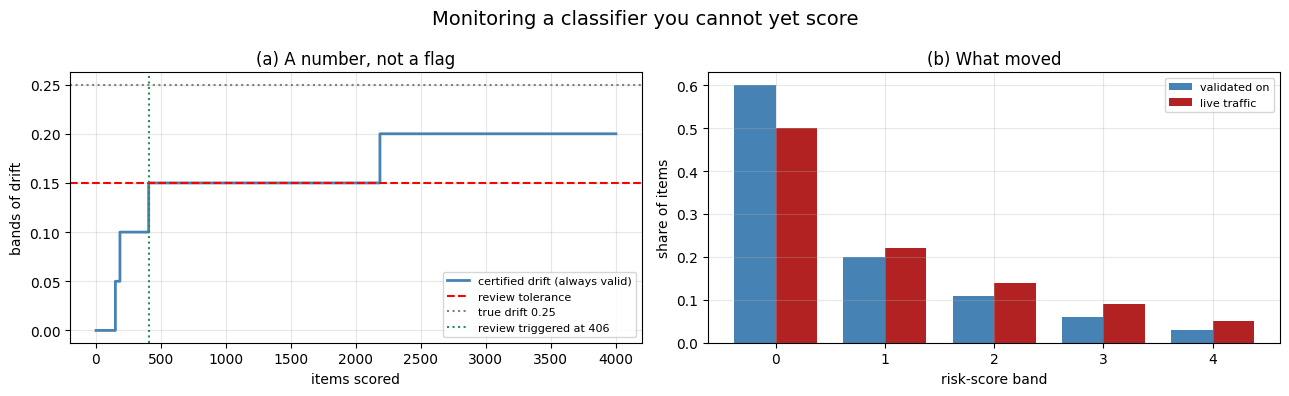

In [13]:
rng = np.random.default_rng(7)

SCORE_BANDS = np.arange(5, dtype=float)
band_cost = np.abs(SCORE_BANDS[:, None] - SCORE_BANDS[None, :])

validated_distribution = np.array([0.60, 0.20, 0.11, 0.06, 0.03])
live_distribution = np.array([0.50, 0.22, 0.14, 0.09, 0.05])
REVIEW_TOLERANCE = 0.15

true_drift = WassersteinNull(validated_distribution, band_cost, 0.0).wasserstein_distance(
    live_distribution
)

drift_sequence = WassersteinDistanceSequence(
    validated_distribution, band_cost, radii=np.linspace(0, 0.5, 11),
    significance_level=ALPHA,
)

bounds, trigger = [], None
for item in range(4000):
    step = drift_sequence.update(int(rng.choice(5, p=live_distribution)))
    bounds.append(step.lower_bound)
    if trigger is None and step.lower_bound > REVIEW_TOLERANCE:
        trigger = item + 1

print(f"true score drift               : {true_drift:.3f} bands")
print(f"review tolerance               : {REVIEW_TOLERANCE:.2f} bands")
print(f"review triggered at item       : {trigger:,}")
print(f"certified drift after 1,000    : {bounds[999]:.2f} bands")
print(f"certified drift after 4,000    : {bounds[-1]:.2f} bands")
print()
print("Zero labels were used. The escalation reads: 'the live score distribution has")
print("moved at least 0.20 bands from the distribution this model was validated on,")
print("against a 0.15 tolerance - pull the labelling queue forward.'")
print()
print("What this does not say: that accuracy dropped. It says the model is no longer")
print("operating on the data it was signed off against, which is the honest claim and")
print("the one that gets the labelling budget approved.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.step(range(1, 4001), bounds, where='post', lw=2, color='steelblue',
        label='certified drift (always valid)')
ax.axhline(REVIEW_TOLERANCE, color='red', ls='--', label='review tolerance')
ax.axhline(true_drift, color='grey', ls=':', label=f'true drift {true_drift:.2f}')
if trigger:
    ax.axvline(trigger, color='seagreen', ls=':', label=f'review triggered at {trigger:,}')
ax.set_xlabel('items scored'); ax.set_ylabel('bands of drift')
ax.set_title('(a) A number, not a flag')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
width = 0.38
ax.bar(SCORE_BANDS - width / 2, validated_distribution, width,
       label='validated on', color='steelblue')
ax.bar(SCORE_BANDS + width / 2, live_distribution, width,
       label='live traffic', color='firebrick')
ax.set_xlabel('risk-score band'); ax.set_ylabel('share of items')
ax.set_title('(b) What moved')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Monitoring a classifier you cannot yet score', fontsize=14)
plt.tight_layout()
plt.show()

# 8. The Playbook

Seven businesses, one framework. What transfers:

| Situation | Ask this | Tool |
|---|---|---|
| You publish probabilities people spend money on | are they calibrated, guaranteed? | defensive forecasting (section 1) |
| A deployed model has drifted out of calibration | can we fix it without retraining? | defensive forecasting as an online layer |
| Someone else quotes a spread | is the whole spread wrong? | `PolytopeNull` + `BettingProtocol` |
| An SLO is about the tail | what fraction breaches? | rate test on the exceedance indicator |
| Thousands of units, small on-call team | who do we work on today? | engine + evidence ranking, truncated at capacity |
| The action is irreversible | what can we never take back? | `adjusted_e_bh` |
| The action is cheap and reversible | what is most likely broken? | `e_bh` or the raw ranking |
| Reserves, risk, anything tail-shaped | has volatility moved? | `SequentialTesting(test_type="variance")` |
| Groups to compare | are these k things the same? | `KSampleSequentialTest` |
| Known-bad records in the pipeline | is it the process or the scanner? | `ContaminationNull` |
| "Different" is guaranteed, "worse" is the question | has it moved more than we tolerate? | `WassersteinNull` + `WassersteinDistanceSequence` |
| Labels arrive far too late | what can we monitor with no labels? | drift bound on the score distribution |
| Streams share a cause | can we still merge them? | `ArithmeticMeanMerger`, always |

**Six rules that survived contact with all seven cases:**

1. **Capital is evidence.** 20x licenses a decision at the 5% level, however often you
   looked. It is also a sentence an executive can act on without a statistics degree.
2. **Test the quantity the business argues in.** Bands of severity, breaching requests,
   judge points, basis points of slippage. If the test output needs translating before
   anyone can act, test something else.
3. **Separate the decision from the estimate.** Stopping rules are safe at any time;
   *estimates* taken at a stopping time during a transient are not. Gate decisions on
   evidence, take numbers from a stable window.
4. **Classify every action as reversible or not, before choosing the statistics.** Nearly
   every monitoring system needs both a fast reversible list and a slow permanent one.
5. **Independence is a claim you must defend.** Services share clusters, creatives share
   audiences, merchants share categories. When in doubt, arithmetic mean - weaker and
   correct beats sharper and wrong.
6. **Standardise before you hand data to the engine.** The mixtures are tuned for
   unit-variance inputs. Section 3 detected nothing at all until the exceedance rates
   were converted to standard deviations; it then detected everything.

**Where else to look:** `toolkit-tour.ipynb` for every tool and what is still under
repair, `commercial-case-studies.ipynb` for three cases worked at greater depth, and the
`imprecise-forecasters`, `sparse-anomaly` and `stein` notebooks for the specialist
constructions.